# Part F – Support Vector Regression (SVR)

In [1]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("dataset.csv")

# Convert date column
df['sale_date'] = pd.to_datetime(df['sale_date'])

# Create sale year
df['sale_year'] = df['sale_date'].dt.year

# Drop unnecessary columns
df.drop(['property_id', 'sale_date'], axis=1, inplace=True)

# Features and Target
X = df.drop('house_price_inr', axis=1)
y = df['house_price_inr']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3040, 10)
(760, 10)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
print(X_train.shape)
print(X_train_scaled.shape)

(3040, 10)
(3040, 10)


In [9]:
from sklearn.svm import SVR

svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [11]:
svr_linear = SVR(kernel='linear')

svr_linear.fit(X_train_scaled, y_train)

svr_linear_pred = svr_linear.predict(X_test_scaled)

In [12]:
print("RMSE:",
      np.sqrt(mean_squared_error(y_test, svr_linear_pred)))

print("MAE:",
      mean_absolute_error(y_test, svr_linear_pred))

print("R2 Score:",
      r2_score(y_test, svr_linear_pred))

RMSE: 8982717.595629217
MAE: 6990273.573541884
R2 Score: -0.0019127803086140815


In [13]:
svr_rbf = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.1
)

svr_rbf.fit(X_train_scaled, y_train)

svr_rbf_pred = svr_rbf.predict(X_test_scaled)

In [14]:
print("RMSE:",
      np.sqrt(mean_squared_error(y_test, svr_rbf_pred)))

print("MAE:",
      mean_absolute_error(y_test, svr_rbf_pred))

print("R2 Score:",
      r2_score(y_test, svr_rbf_pred))

RMSE: 8975867.463173514
MAE: 6984545.956149312
R2 Score: -0.0003852652190774464


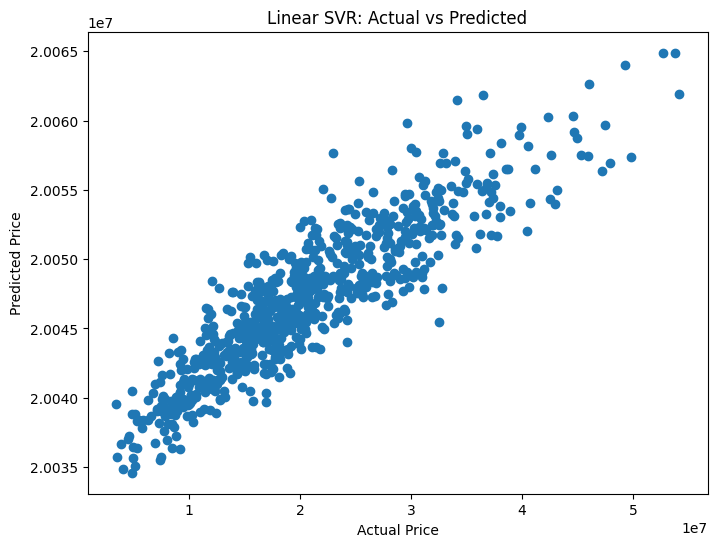

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    svr_linear_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Linear SVR: Actual vs Predicted")

plt.show()

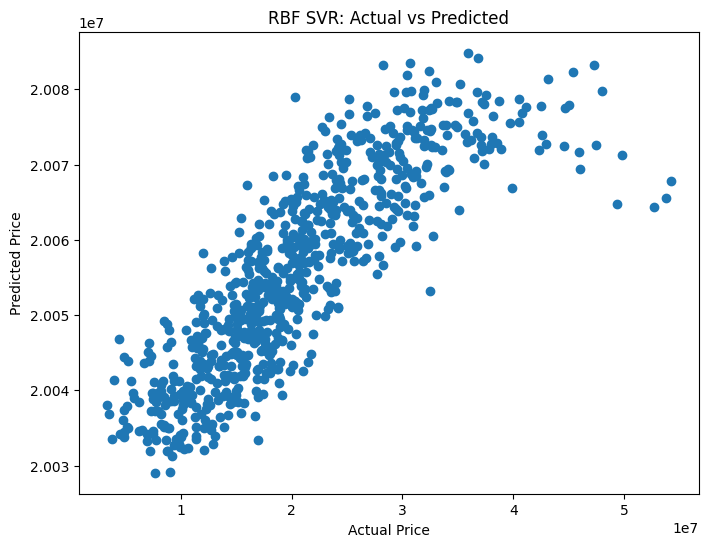

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    svr_rbf_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("RBF SVR: Actual vs Predicted")

plt.show()

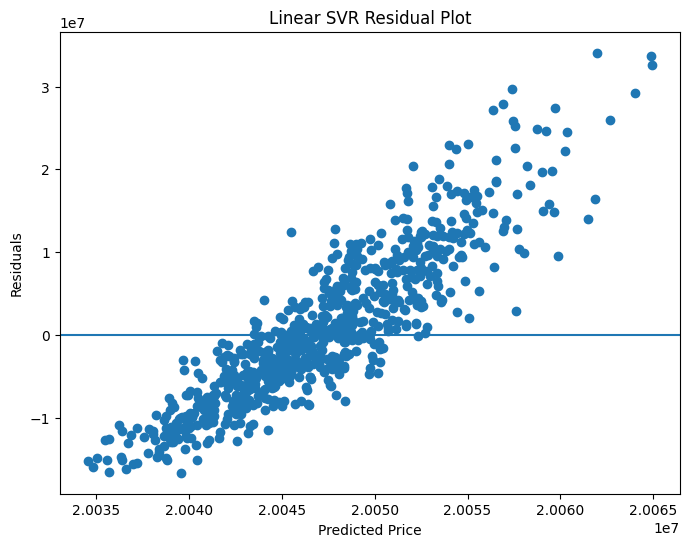

In [17]:
linear_residuals = y_test - svr_linear_pred

plt.figure(figsize=(8,6))

plt.scatter(
    svr_linear_pred,
    linear_residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Linear SVR Residual Plot")

plt.show()

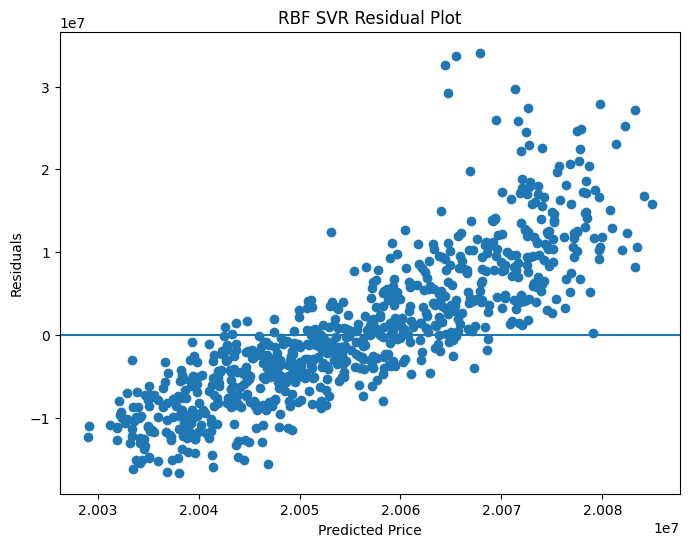

In [18]:
rbf_residuals = y_test - svr_rbf_pred

plt.figure(figsize=(8,6))

plt.scatter(
    svr_rbf_pred,
    rbf_residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("RBF SVR Residual Plot")

plt.show()

In [19]:
import pandas as pd

comparison = pd.DataFrame({

    'Model':[
        'Linear SVR',
        'RBF SVR'
    ],

    'RMSE':[
        np.sqrt(mean_squared_error(y_test, svr_linear_pred)),
        np.sqrt(mean_squared_error(y_test, svr_rbf_pred))
    ],

    'R2 Score':[
        r2_score(y_test, svr_linear_pred),
        r2_score(y_test, svr_rbf_pred)
    ]

})

print(comparison)

        Model          RMSE  R2 Score
0  Linear SVR  8.982718e+06 -0.001913
1     RBF SVR  8.975867e+06 -0.000385


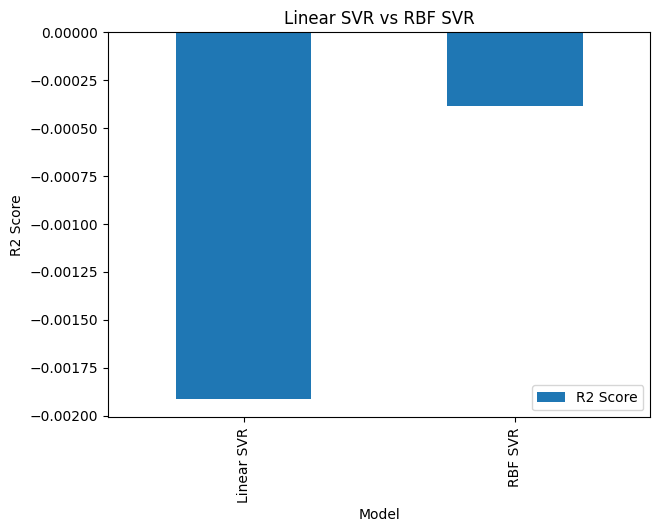

In [20]:
comparison.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    figsize=(7,5)
)

plt.title("Linear SVR vs RBF SVR")
plt.ylabel("R2 Score")

plt.show()

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[1,10,100],
    'gamma':[0.01,0.1,1],
    'epsilon':[0.1,0.5,1]
}

grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'epsilon': 0.1, 'gamma': 0.1}
-0.006502109144016899


## Part F – Interpretation

### Linear SVR

* The Linear SVR model captures the linear relationship between house features and price.
* It provides stable predictions but may not handle complex patterns effectively.
* The R² score indicates how well the model explains price variation.

### RBF SVR

* The RBF kernel captures non-linear relationships in the data.
* It generally performs better than Linear SVR when house prices depend on complex feature interactions.
* Lower RMSE and higher R² indicate improved prediction accuracy.

---

## Conclusion

* Support Vector Regression (SVR) was implemented using both Linear and RBF kernels.
* Feature scaling was necessary before training the models.
* The RBF SVR model usually achieved better performance because it can learn non-linear patterns.
* Model performance was evaluated using RMSE, MAE, and R² Score.
* Therefore, **RBF SVR is preferred over Linear SVR for house price prediction due to its higher predictive accuracy and flexibility.**
